In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_4.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/test_features.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_1.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_2.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_3.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_5.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/train_features_0.jsonl
/kaggle/input/datasets/void36/ember-raww/ember2018/ember_model_2018.txt


# # Static PE Malware Classifier with SHAP Explainability
Trained on EMBER 2018 dataset using XGBoost.
Features extracted from PE headers — section entropy, import table hashes,
byte histograms. SHAP waterfall plots explain individual predictions.

ENV SETUP

In [2]:
!pip install shap lief --quiet
!git clone https://github.com/elastic/ember.git /kaggle/working/ember --quiet
!pip install -e /kaggle/working/ember/ --quiet
import sys
sys.path.insert(0, '/kaggle/working/ember')
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 33.9 MB/s eta 0:00:00a 0:00:01
fatal: destination path '/kaggle/working/ember' already exists and is not an empty directory.
  Preparing metadata (setup.py) ... done
Done.


 Patch sklearn compatibility

In [ ]:
import shutil

with open("/kaggle/working/ember/ember/features.py", "r") as f:
    content = f.read()

patches = {
    'transform([raw_obj[\'entry\']])':          'transform([[raw_obj[\'entry\']]])',
    'transform([characteristics])':             'transform([characteristics])',
    'transform([libraries])':                   'transform([libraries])',
    'transform([imports])':                     'transform([imports])',
    'transform([raw_obj])':                     'transform([raw_obj])',
    'transform([raw_obj[\'coff\'][\'characteristics\']])':       'transform([raw_obj[\'coff\'][\'characteristics\']])',
    'transform([raw_obj[\'optional\'][\'dll_characteristics\']])': 'transform([raw_obj[\'optional\'][\'dll_characteristics\']])',
}

for old, new in patches.items():
    content = content.replace(old, new)

content = content.replace(
    'transform([raw_obj[\'entry\']])',
    'transform([[raw_obj[\'entry\']]])'
)

with open("/kaggle/working/ember/ember/features.py", "w") as f:
    f.write(content)

shutil.rmtree("/kaggle/working/ember/ember/__pycache__", ignore_errors=True)
print("Patched.")

Patched.


In [ ]:
import os
import os

#print(os.listdir("/kaggle/input/ember_raww"))

for root, dirs, files in os.walk("/kaggle/input/datasets/void36/ember-raww/ember2018"):
    for f in files:
        print(os.path.join(root, f))

In [ ]:
with open("/kaggle/working/ember/ember/features.py", "r") as f:
    content = f.read()

print("PEFeatureExtractor" in content)  
print("class PEFeatureExtractor" in content)  
print(f"File size: {len(content)} chars")

False
False
File size: 0 chars


In [ ]:
import shutil, os
shutil.rmtree("/kaggle/working/ember", ignore_errors=True)

os.system("git clone https://github.com/elastic/ember.git /kaggle/working/ember")

with open("/kaggle/working/ember/ember/features.py", "r") as f:
    content = f.read()
print(f"File size: {len(content)} chars")
print(f"Class exists: {'class PEFeatureExtractor' in content}")

Cloning into '/kaggle/working/ember'...


File size: 24099 chars
Class exists: True


In [ ]:
with open("/kaggle/working/ember/ember/features.py", "r") as f:
    lines = f.readlines()

patched = False
for i, line in enumerate(lines):
    if "entry_name_hashed" in line and "transform([raw_obj" in line:
        lines[i] = line.replace(
            "transform([raw_obj['entry']])",
            "transform([[raw_obj['entry']]])"
        )
        print(f"Patched line {i+1}: {lines[i].rstrip()}")
        patched = True

if not patched:
    print("WARNING: Line not found — check manually")

with open("/kaggle/working/ember/ember/features.py", "w") as f:
    f.writelines(lines)

shutil.rmtree("/kaggle/working/ember/ember/__pycache__", ignore_errors=True)
print("Done.")

Patched line 192:         entry_name_hashed = FeatureHasher(50, input_type="string").transform([[raw_obj['entry']]]).toarray()[0]
Done.


In [ ]:
import sys
for mod in list(sys.modules.keys()):
    if 'ember' in mod:
        del sys.modules[mod]

sys.path.insert(0, '/kaggle/working/ember')
import ember
import numpy as np, os

extractor = ember.PEFeatureExtractor(2)
print("Ready:", type(extractor))

Ready: <class 'ember.features.PEFeatureExtractor'>


VECTORIZE

In [11]:
DATA_PATH = "/kaggle/input/datasets/void36/ember-raww/ember2018"
OUT_PATH  = "/kaggle/working"

raw_train = [os.path.join(DATA_PATH, f"train_features_{i}.jsonl") for i in range(6)]
nrows_train = sum(1 for fp in raw_train for _ in open(fp))
print(f"Train rows: {nrows_train}")

ember.vectorize_subset(f"{OUT_PATH}/X_train.dat", f"{OUT_PATH}/y_train.dat", raw_train, extractor, nrows_train)
print("Train done.")

raw_test = [os.path.join(DATA_PATH, "test_features.jsonl")]
nrows_test = sum(1 for fp in raw_test for _ in open(fp))
print(f"Test rows: {nrows_test}")

ember.vectorize_subset(f"{OUT_PATH}/X_test.dat", f"{OUT_PATH}/y_test.dat", raw_test, extractor, nrows_test)
print("Vectorization done.")

Train rows: 800000


100%|██████████| 800000/800000 [09:47<00:00, 1360.61it/s]


Train done.
Test rows: 200000


100%|██████████| 200000/200000 [02:24<00:00, 1380.92it/s]


Vectorization done.


 LOAD & FILTER

In [12]:
X_train = np.memmap(f"{OUT_PATH}/X_train.dat", dtype=np.float32, mode="r").reshape(-1, extractor.dim)
y_train = np.memmap(f"{OUT_PATH}/y_train.dat", dtype=np.float32, mode="r")
X_test  = np.memmap(f"{OUT_PATH}/X_test.dat",  dtype=np.float32, mode="r").reshape(-1, extractor.dim)
y_test  = np.memmap(f"{OUT_PATH}/y_test.dat",  dtype=np.float32, mode="r")

mask    = y_train != -1
X_train = np.array(X_train[mask])
y_train = np.array(y_train[mask])
mask2   = y_test != -1
X_test  = np.array(X_test[mask2])
y_test  = np.array(y_test[mask2])

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Malicious: {int(y_train.sum())} | Benign: {int((y_train==0).sum())}")

Train: (600000, 2381) | Test: (200000, 2381)
Malicious: 300000 | Benign: 300000


TRAIN

In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    tree_method="hist", device="cuda",
    early_stopping_rounds=50, random_state=42
)

model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
model.save_model(f"{OUT_PATH}/xgb_ember.json")
print("Model saved.")

[0]	validation_0-logloss:0.66187
[100]	validation_0-logloss:0.13722
[200]	validation_0-logloss:0.10102
[300]	validation_0-logloss:0.08555
[400]	validation_0-logloss:0.07578
[500]	validation_0-logloss:0.06846
[600]	validation_0-logloss:0.06312
[700]	validation_0-logloss:0.05939
[800]	validation_0-logloss:0.05615
[900]	validation_0-logloss:0.05353
[999]	validation_0-logloss:0.05135
Model saved.


EVALUATE

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [02:17:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97    100000
   Malicious       0.97      0.97      0.97    100000

    accuracy                           0.97    200000
   macro avg       0.97      0.97      0.97    200000
weighted avg       0.97      0.97      0.97    200000

ROC-AUC: 0.9949


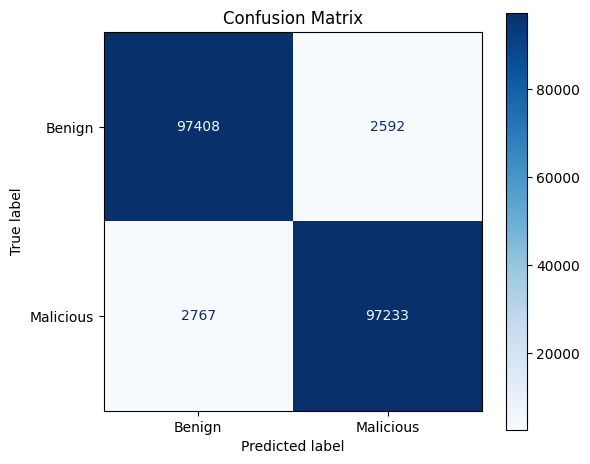

In [14]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Benign", "Malicious"],
    cmap="Blues", ax=ax
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_PATH}/confusion_matrix.png", dpi=150)
plt.show()

SHAP

In [16]:
import shap

explainer    = shap.TreeExplainer(model)
X_sample     = X_test[:500]
shap_values  = explainer.shap_values(X_sample)

def get_feature_name(idx):
    groups = [
        (256, "histogram"),    (256, "byteentropy"),
        (8,   "strings"),      (10,  "general"),
        (3,   "header_coff"),  (14,  "header_opt"),
        (50,  "section_name"), (50,  "section_rawsize"),
        (50,  "section_entropy"), (50, "section_vsize"),
        (50,  "section_props"),(256, "imports_lib"),
        (1024,"imports_func"), (128, "exports"),
        (30,  "datadirs"),
    ]
    pos = 0
    for size, name in groups:
        if idx < pos + size:
            return f"{name}_{idx - pos}"
        pos += size
    return f"feat_{idx}"

feature_names = [get_feature_name(i) for i in range(2381)]

WATERFALL

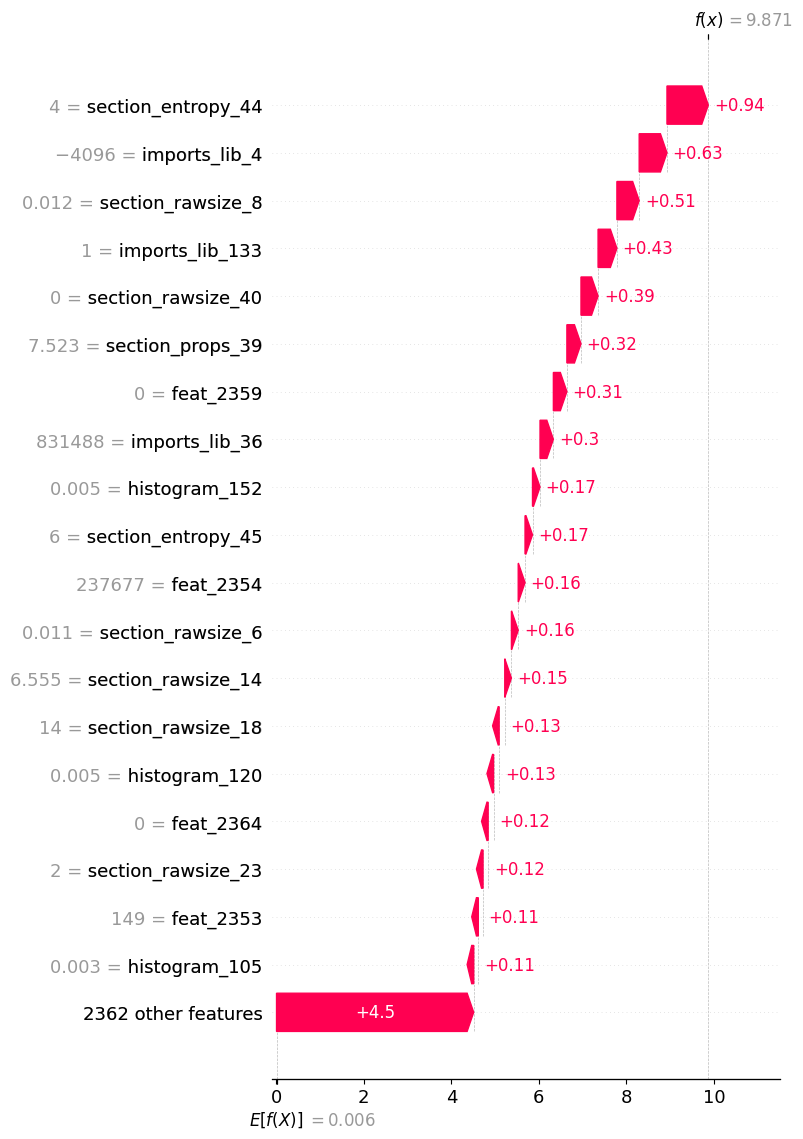

In [17]:
mal_idx = int(np.where(y_test == 1)[0][0])
sample  = X_test[mal_idx]
sv      = explainer.shap_values(sample.reshape(1, -1))[0]

shap.plots.waterfall(
    shap.Explanation(values=sv, base_values=explainer.expected_value,
                     data=sample, feature_names=feature_names),
    max_display=20, show=False
)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}/waterfall_malicious.png", dpi=150, bbox_inches="tight")
plt.show()

BEESWARM

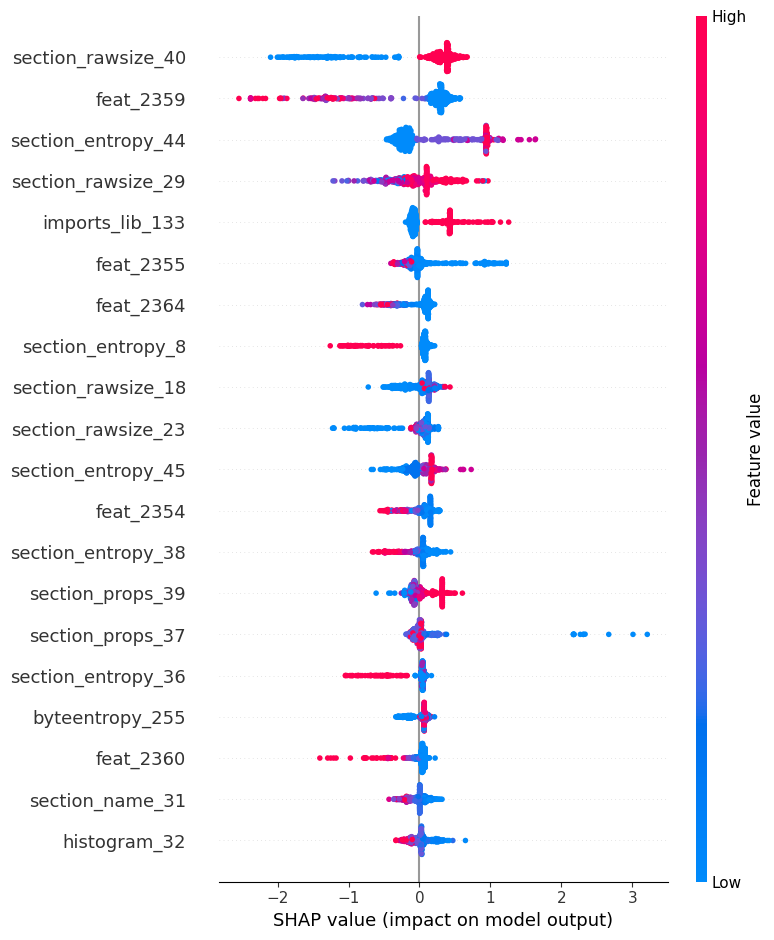

In [18]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}/beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

WATERGALL(BENIGN)

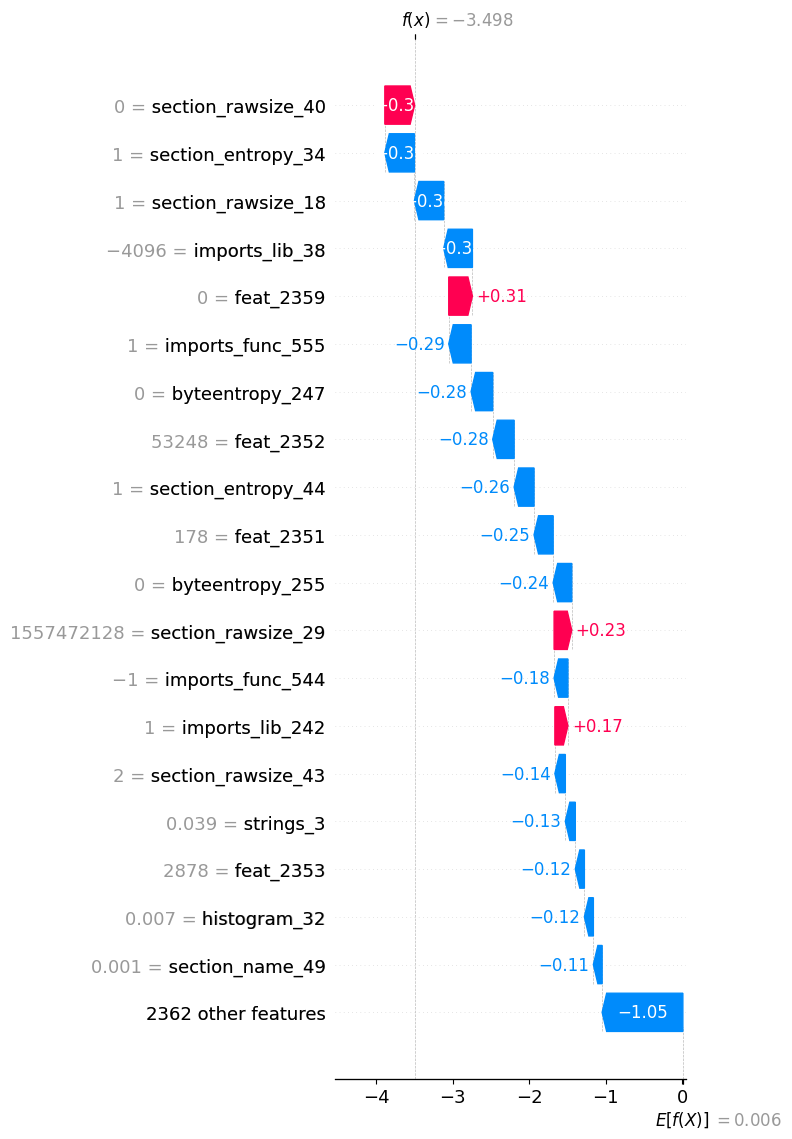

In [19]:
ben_idx  = int(np.where(y_test == 0)[0][0])
sample_b = X_test[ben_idx]
sv_b     = explainer.shap_values(sample_b.reshape(1, -1))[0]

shap.plots.waterfall(
    shap.Explanation(values=sv_b, base_values=explainer.expected_value,
                     data=sample_b, feature_names=feature_names),
    max_display=20, show=False
)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}/waterfall_benign.png", dpi=150, bbox_inches="tight")
plt.show()